Dataset Preview:
    Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Accuracy: 1.0
Error Rate: 0.0
Precision: 1.0
Recall: 1.0

TP, FP, TN, FN for each class:

Class 0:
TP = 19 FP = 0 FN = 0 TN = 26

Class 1:
TP = 13 FP = 0 FN = 0 TN = 32

Class 2:
TP = 13 FP = 0 FN = 0 TN = 32



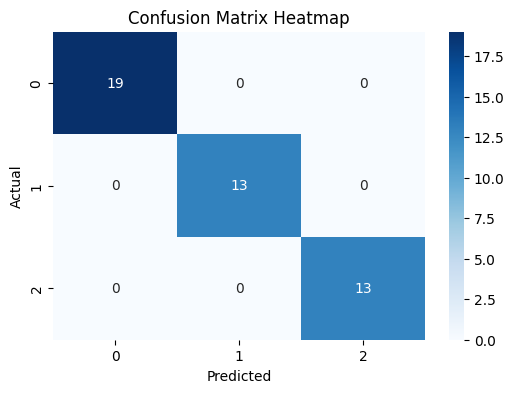

In [2]:
# =========================================================
# DATA ANALYTICS III - NAIVE BAYES (IRIS DATASET)
# =========================================================

# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

# =========================================================
# 1. LOAD DATASET
# =========================================================

df = pd.read_csv("iris.csv")   # Make sure iris.csv is in same folder

print("Dataset Preview:\n", df.head())

# Features and target
X = df.iloc[:, :-1]   # all columns except last
y = df.iloc[:, -1]    # target column

# =========================================================
# 2. TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# =========================================================
# 3. APPLY NAIVE BAYES
# =========================================================

model = GaussianNB()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# =========================================================
# 4. CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)

# =========================================================
# 5. METRICS CALCULATION
# =========================================================

accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy

precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

print("\nAccuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)

# =========================================================
# 6. TP, FP, TN, FN (FOR EACH CLASS)
# =========================================================

print("\nTP, FP, TN, FN for each class:\n")

for i in range(len(cm)):
    TP = cm[i][i]
    FP = sum(cm[:, i]) - TP
    FN = sum(cm[i, :]) - TP
    TN = sum(sum(cm)) - (TP + FP + FN)

    print(f"Class {i}:")
    print("TP =", TP, "FP =", FP, "FN =", FN, "TN =", TN)
    print()

# =========================================================
# 7. CONFUSION MATRIX HEATMAP
# =========================================================

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

